# 토큰화

토큰화(tokenization)는 자연어를 **모델이 이해할 수 있는 또는 모델이 다룰 수있는 기본 단위(Token)** 분할하는 과정을 말한다.   
토큰으로 나누는 단위는 설계에 따라 문장, 어절, 형태소, 서브워드, 문자, 자모/알파벳 등 다양한 방식으로 나눌 수 있다.   
- 예
```bash
원문: "자연어 처리는 재미있다"
토큰화: ["자연어", "처리", "는", "재미있다"]
```

## 토큰화 방식
- **단어 기반 토큰화(Word-Level Tokenization)**
    - 어절(공백으로 구분) 또는 형태소 단위로 단어를 나누는 전통적인 방식이다.
    - **한국어**는 교착어로 하나의 단어에 다양한 조사/어미가 결합된다. 그래서 어절단위로 토큰화할 경우 어휘사전의 크기가 기하급수적으로 늘어나는 문제가 있다.
      - 예) "학교", "학교가", "학교를", "학교에", "학교에서", "학교로", "학교의", ...
    - 이로 인해 미등록어휘(OOV - Out of Vocabulary)의 증가, 같은 의미를 가지는 단어들이 Vocab에 중복 등록, 메모리 낭비, 학습효율성 저하 등 다양한 문제가 생긴다.
    - 그래서 **한국어의 경우 형태소 단위 토큰화**가 필요하다.

- **서브워드 기반(Subword-level) — BPE, WordPiece, Unigram**
    - Transformer 기반 모델(BERT, GPT, LLaMA 등)에서 표준으로 사용하는 방식.
    - 단어를 기준으로 토큰화하지 않고 **문자(character)와 단어(word)의 중간 수준인 서브워드(subword) 단위로 토큰화**한다.
    - **동작 원리**:
        - 자주 등장하는 문자열 조합(서브워드)을 하나의 토큰으로 구성한다.
        - 빈도가 높은 단어는 하나의 토큰으로, 빈도가 낮거나 희귀한 단어는 여러 서브워드로 분할한다.
    - **예시**:
        ```bash
        입력: "나는 밥을 먹었습니다. 나는 어제 밥을 했습니다."
        
        서브워드 토큰화 결과 (예시):
        ["나는", "밥", "을", "먹", "었", "습니다", ".", "나는", "어제", "밥", "을", "하", "었", "습니다", "."]
        ```
    - **장점**:
        - **미등록 단어(OOV) 문제 해결**: 모든 단어를 서브워드 조합으로 표현 가능
        - **어휘 사전 크기 최적화**: 단어 단위보다 작고, 문자 단위보다 효율적
        - **다국어 지원**: 언어에 구애받지 않는 범용적 토큰화
        - **형태론적 의미 포착**: 접두사, 접미사 등의 의미를 학습 가능
    - **주요 알고리즘**:
        - **BPE (Byte Pair Encoding)**: 가장 빈번한 연속 바이트/문자 쌍을 반복적으로 병합
        - **WordPiece**: BERT에서 사용, BPE와 유사하지만 likelihood 기반으로 병합
        - **Unigram**: 확률 모델 기반으로 최적의 서브워드 분할 선택


# 한국어 형태소 분석기

- kiwipiepy와 konlpy 는 대표적인 한국어 형태소 분석기이다.

## kiwipiepy
**kiwipiepy**는 C++로 구현된 한국어 형태소 분석기 Kiwi(Korean Intelligent Word Identifier)를 Python 환경에서 사용할 수 있도록 한 라이브러리이다.

- 빠른 속도  
- 최신 품사 체계 지원  
- 사용자 사전 확장 용이  
- 최근 가장 널리 쓰이는 한국어 토크나이저 중 하나이다.
- https://github.com/bab2min/kiwipiepy
  
### 설치 방법

```bash
pip install kiwipiepy
```


### 주요 클래스 및 함수

#### Kiwi 클래스
- Kiwi의 핵심 클래스이며, 형태소 분석과 토큰화 기능을 모두 제공한다.
- Kiwi 품사는 세종 말뭉치를 기반으로 한다.
  - 품사 시작 글자
  - 체언(명사, 대명사): `N`, 용언(동사, 형용사): `V`, 수식언(관형사, 부사): `M`,  관계언(조사):`J`, 어미: `E`, 기호: `S`
    - https://github.com/bab2min/kiwipiepy?tab=readme-ov-file#%ED%92%88%EC%82%AC-%ED%83%9C%EA%B7%B8
- 메소드
  - `tokenzie(text)`: 형태소 분석 기반 토큰화 수행
  - `analyze(text)`: tokenize보다 좀 더 상세한 분석을 진행한다. 여러 분석결과를 조회할 수있다.
  - `add_user_word(word, pos, score)`: 사전에 직접 단어 등록
  - `space(text)`: 띄어 쓰기 교정

## KoNLPy(코엔엘파이)
- KoNLPY는 한국어 자연어 처리(Natural Language Processing) 파이썬 라이브러리이다.  한국어 처리를 위한 tokenize, 형태소 분석, 어간추출, 품사부착(POS Tagging) 등의 기능을 제공한다.
- http://KoNLPy.org/ko/latest/
- 기존의 개발된 다양한 형태소 분석기를 통합해서 동일한 interface로 호출 할 수 있게 해준다.

### KoNLPy 설치
- 설치 순서
  1. Java 실행환경 설치
  2. JPype1 설치
  3. koNLPy 설치

1. **Java 설치**
  - https://www.oracle.com/java/technologies/downloads/
    - OS에 맞는 설치 버전을 다운받아 설치한다.
    - MAC: ARM일 경우: **ARM64 CPU** - ARM64 DMG Installer, **Intel CPU**: x64 DMG Installer
  - 시스템 환경변수 설정
      - `JAVA_HOME` : 설치 경로 지정
      - `Path` : `설치경로\bin` 경로 지정

2. **JPype1 설치**
   - 파이썬에서 자바 모듈을 호출하기 위한 연동 패키지
   - 설치: `pip install JPype1`

3. **KoNLPy 설치**
- `pip install konlpy`

In [1]:
%%bash
apt-get update
apt-get install g++ openjdk-8-jdk python-dev pyhon3-dev
pip3 install jpype1
pip3 install konlpy

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:4 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:6 https://cli.github.com/packages stable InRelease
Get:7 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:9 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,290 kB]
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:11 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [6,008 kB]
Hit:12 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/restr

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
E: Package 'python-dev' has no installation candidate
E: Unable to locate package pyhon3-dev


In [2]:
%env JAVA_HOME "/usr/lib/jvm/java-8-openjdk-amd64"

env: JAVA_HOME="/usr/lib/jvm/java-8-openjdk-amd64"


In [3]:
import konlpy

### 형태소 분석기/사전
- 형태소 사전을 내장하고 있으며 형태소 분석 함수들을 제공하는 모듈

#### KoNLPy 제공 형태소 분석기
- Open Korean Text
    - 트위터에서 개발
    - https://github.com/open-korean-text/open-korean-text
- Hannanum(한나눔)
    - KAIST Semantic Web Research Center 에서 개발
    - http://semanticweb.kaist.ac.kr/hannanum/
- Kkma(꼬꼬마)
    - 서울대학교 IDS(Intelligent Data Systems) 연구실 개발.
    - http://kkma.snu.ac.kr/
- Komoran(코모란)
    - Shineware에서 개발.
    - 오픈소스버전과 유료버전이 있음
    - https://github.com/shin285/KOMORAN
- Mecab(메카브)
    - 일본어용 형태소 분석기를 한국에서 사용할 수 있도록 수정
    - windows에서는 설치가 안됨
    - https://bitbucket.org/eunjeon/mecab-ko


### 형태소 분석기 공통 메소드
- `morphs(string)` : 형태소 단위로 토큰화(tokenize)
- `nouns(string)` : 명사만 추출하여 토큰화(tokenize)    
- `pos(string)`: 품사 부착
    - 형태소 분석기 마다 사용하는 품사태그가 다르다.
        - https://konlpy-ko.readthedocs.io/ko/v0.5.2/morph/
- `tagset`: 형태소 분석기가 사용하는 품사태그 설명하는 속성.

In [4]:
from konlpy.tag import Okt

okt = Okt()



In [5]:
# 형태소 기반으로 토큰화

txt = "자연어 처리 공부를 어제 시작했습니다. 자연어 처리는 어렵습니다."
result = okt.morphs(txt)

result

['자연어',
 '처리',
 '공부',
 '를',
 '어제',
 '시작',
 '했습니다',
 '.',
 '자연어',
 '처리',
 '는',
 '어렵습니다',
 '.']

In [6]:
# 명사만 추출해서 토큰화

result_nouns = okt.nouns(txt)
result_nouns

['자연어', '처리', '공부', '어제', '시작', '자연어', '처리']

In [7]:
# 품사 부착(POS Tagging)
result_pos  = okt.pos(txt)
result_pos

[('자연어', 'Noun'),
 ('처리', 'Noun'),
 ('공부', 'Noun'),
 ('를', 'Josa'),
 ('어제', 'Noun'),
 ('시작', 'Noun'),
 ('했습니다', 'Verb'),
 ('.', 'Punctuation'),
 ('자연어', 'Noun'),
 ('처리', 'Noun'),
 ('는', 'Josa'),
 ('어렵습니다', 'Adjective'),
 ('.', 'Punctuation')]

In [8]:
# 조사, 구두점 제거
result = []
for word, tag in result_pos :
  if tag not in ['Josa', 'Punctuation']:
    result.append(word)

result

['자연어', '처리', '공부', '어제', '시작', '했습니다', '자연어', '처리', '어렵습니다']

In [9]:
# 품사 tag를 확인
okt.tagset

{'Adjective': '형용사',
 'Adverb': '부사',
 'Alpha': '알파벳',
 'Conjunction': '접속사',
 'Determiner': '관형사',
 'Eomi': '어미',
 'Exclamation': '감탄사',
 'Foreign': '외국어, 한자 및 기타기호',
 'Hashtag': '트위터 해쉬태그',
 'Josa': '조사',
 'KoreanParticle': '(ex: ㅋㅋ)',
 'Noun': '명사',
 'Number': '숫자',
 'PreEomi': '선어말어미',
 'Punctuation': '구두점',
 'ScreenName': '트위터 아이디',
 'Suffix': '접미사',
 'Unknown': '미등록어',
 'Verb': '동사'}

In [10]:
from konlpy.tag import Komoran
komoran = Komoran()
komoran.tagset

{'EC': '연결 어미',
 'EF': '종결 어미',
 'EP': '선어말어미',
 'ETM': '관형형 전성 어미',
 'ETN': '명사형 전성 어미',
 'IC': '감탄사',
 'JC': '접속 조사',
 'JKB': '부사격 조사',
 'JKC': '보격 조사',
 'JKG': '관형격 조사',
 'JKO': '목적격 조사',
 'JKQ': '인용격 조사',
 'JKS': '주격 조사',
 'JKV': '호격 조사',
 'JX': '보조사',
 'MAG': '일반 부사',
 'MAJ': '접속 부사',
 'MM': '관형사',
 'NA': '분석불능범주',
 'NF': '명사추정범주',
 'NNB': '의존 명사',
 'NNG': '일반 명사',
 'NNP': '고유 명사',
 'NP': '대명사',
 'NR': '수사',
 'NV': '용언추정범주',
 'SE': '줄임표',
 'SF': '마침표, 물음표, 느낌표',
 'SH': '한자',
 'SL': '외국어',
 'SN': '숫자',
 'SO': '붙임표(물결,숨김,빠짐)',
 'SP': '쉼표,가운뎃점,콜론,빗금',
 'SS': '따옴표,괄호표,줄표',
 'SW': '기타기호 (논리수학기호,화폐기호)',
 'VA': '형용사',
 'VCN': '부정 지정사',
 'VCP': '긍정 지정사',
 'VV': '동사',
 'VX': '보조 용언',
 'XPN': '체언 접두사',
 'XR': '어근',
 'XSA': '형용사 파생 접미사',
 'XSN': '명사파생 접미사',
 'XSV': '동사 파생 접미사'}

In [12]:
# 원형복원(표제어추출) - OKT의 기능( 다른데엔 없음! )
result = okt.morphs(txt, stem = True)
result
# 했다 = 하다 처럼 원형으로 추출됨

['자연어', '처리', '공부', '를', '어제', '시작', '하다', '.', '자연어', '처리', '는', '어렵다', '.']

In [16]:
# 비속어 처리 - Okt 기능
txt = "반갑습니당"

okt.morphs(txt,norm=True) # normalization을 지정하지않으면 반갑 / 습 / 니당 으로 토큰화됨

['반갑습니다']

# WordCloud

WordCloud는 텍스트 데이터에서 단어의 등장 빈도를 시각적으로 표현한 그래픽이다.
- 특징
  - 자주 등장하는 단어일수록 글자 크기가 커진다.
  - 텍스트 전체의 주제를 직관적으로 파악할 수 있다.
  - 문서의 핵심키워드를 빠르게 파악할 수 있어 텍스트 분석에서 탐색적 데이터 분석(EDA) 단계에서 자주 활용된다.
- 설치
  - `pip install wordcloud`

In [22]:
from konlpy.corpus import kolaw
kolaw.fileids() # kolaw에서 헌법을 제공

['constitution.txt']

In [23]:
with kolaw.open('constitution.txt') as f :
  txt = f.read()

txt[:100]

'대한민국헌법\n\n유구한 역사와 전통에 빛나는 우리 대한국민은 3·1운동으로 건립된 대한민국임시정부의 법통과 불의에 항거한 4·19민주이념을 계승하고, 조국의 민주개혁과 평화적 통일의'

- wordcloud 입력 형식은 dictionary - {단어 : 빈도수}
- {"국민":30, "국회":10, "헌법":100}

In [28]:
# 1. 토큰화 - 명사
from konlpy.tag import Okt
okt = Okt()
token_nouns = okt.nouns(txt)

# 2글자 이상인 것만 남기기
print(len(token_nouns))
token_nouns = [token for token in token_nouns if len(token)>=2]
print(len(token_nouns))


token_nouns[:5]

3882
3013


['대한민국', '헌법', '유구', '역사', '전통']

In [31]:
# 단어 개수를 count
from collections import Counter

freq = Counter(token_nouns) # {단어 : 출연개수}

freq

Counter({'대한민국': 11,
         '헌법': 53,
         '유구': 1,
         '역사': 1,
         '전통': 1,
         '우리': 3,
         '국민': 61,
         '운동': 2,
         '건립': 1,
         '임시정부': 1,
         '통과': 1,
         '불의': 2,
         '항거': 1,
         '민주': 6,
         '이념': 1,
         '계승': 2,
         '조국': 3,
         '개혁': 1,
         '평화': 6,
         '통일': 6,
         '사명': 2,
         '각하': 1,
         '정의': 1,
         '인도': 1,
         '동포': 1,
         '로써': 5,
         '민족': 3,
         '단결': 1,
         '공고': 3,
         '모든': 37,
         '사회': 8,
         '폐습': 1,
         '타파': 1,
         '자율': 2,
         '조화': 2,
         '바탕': 1,
         '자유민주': 2,
         '질서': 8,
         '더욱': 1,
         '정치': 9,
         '경제': 18,
         '문화': 4,
         '영역': 4,
         '각인': 1,
         '기회': 3,
         '능력': 3,
         '최고': 2,
         '도로': 1,
         '발휘': 1,
         '자유': 20,
         '권리': 21,
         '책임': 5,
         '의무': 18,
         '완수': 1,
         '생활':

In [32]:
# 빈도수 높은 순서로 n개 조회. top-k
freq.most_common(n=5) # 빈도수 상위 n개 만큼 보여줌

[('법률', 127), ('대통령', 83), ('국가', 73), ('국회', 68), ('국민', 61)]

In [33]:
freq['대통령']

83

In [49]:
ls

constitution_wc.png  sample_data/


In [34]:
# wordcoloud 정의
# 한글 폰트 경로가 필요(Co Lab에 한글 폰트 설치)
!sudo apt install fonts-nanum

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 55 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (8,928 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 121713 files and dire

In [48]:
!ls /usr/share/fonts/truetype/nanum/

NanumBarunGothicBold.ttf   NanumGothicCoding.ttf  NanumSquareB.ttf
NanumBarunGothic.ttf	   NanumGothic.ttf	  NanumSquareRoundB.ttf
NanumGothicBold.ttf	   NanumMyeongjoBold.ttf  NanumSquareRoundR.ttf
NanumGothicCodingBold.ttf  NanumMyeongjo.ttf	  NanumSquareR.ttf


In [37]:
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'

In [43]:
import matplotlib.font_manager as fm
[f. fname for f in fm.fontManager.ttflist if 'malgun' in f.name.lower() ]
# local에 있는건 이런식으로 탐색. nanum은 다른경로인건지 안나옴.

[]

In [65]:
# wordcoloud 구현
from wordcloud import WordCloud

wc = WordCloud(
    font_path=font_path,
    max_words=150, # wordcloud에 나올 최대 단어수 (150개만 나오게 됨). 순서는 빈도가 높은 순
    min_font_size=10, # 제일 빈도수가 적은 단어의 폰트크기(최소 폰트 크기)
    relative_scaling=0.5, # 단어 크기를 빈도 수 비율에 얼마나 민감하게 반영할지 조절하는 값.
    # 0 ~ 1 사이 실수 지정. 0은 빈도 차이를 거의 반영 안함. 1은 빈도수 차이를 크게 반영해 적은 것은 더 작게, 많은 것은 더 크게 반영.
    width=500, # 그래프 크기(pixel값)
    height=400,
    background_color = 'white', # default = black. # hexcode로 지정 가능(#ffff11)
    prefer_horizontal=0.5 # 단어 배치 시, 가로 방향으로 배치될 확률이 50%라는 뜻
)


In [66]:
# 생성 - 값 : {단어:빈도수}
wc_img = wc.generate_from_frequencies(freq)

In [67]:
print(wc_img)

#파일로 저장
wc_img.to_file('constitution_wc.png')

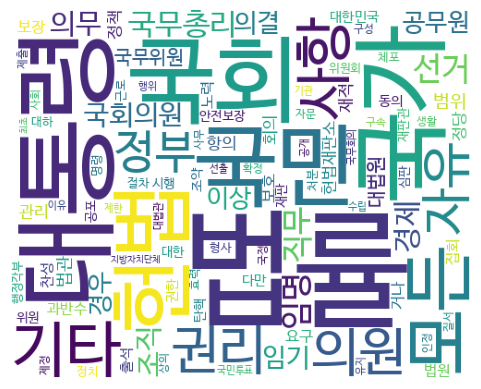

In [68]:
import matplotlib.pyplot as plt

plt.imshow(wc_img)
plt.axis('off') # 경계선을 없애줌
plt.show()